In [2]:
import pandas as pd

In [4]:
nav_history=pd.read_csv(r"C:\Users\aksha\OneDrive\Desktop\BLUE STOCK INTERNSHIP\Mutual-Fund-Analysis\data\processed\nav_history_cleaned.csv")

In [6]:
nav_history.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [8]:
scheme_performance=pd.read_csv(r"C:\Users\aksha\OneDrive\Desktop\BLUE STOCK INTERNSHIP\Mutual-Fund-Analysis\data\processed\scheme_performance_cleaned.csv")

In [12]:
nav_scheme=pd.merge(nav_history,scheme_performance,on='amfi_code',how='left')
nav_scheme.head()

,amfi_code,date,nav,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,...,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,2022-01-03,54.3856,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,...,0.87,0.89,0.88,1.29,14.0,-21.7,14288,1.54,4,Moderate
1,119551,2022-01-04,54.3474,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,...,0.87,0.89,0.88,1.29,14.0,-21.7,14288,1.54,4,Moderate
2,119551,2022-01-05,54.6869,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,...,0.87,0.89,0.88,1.29,14.0,-21.7,14288,1.54,4,Moderate
3,119551,2022-01-06,55.4550,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,...,0.87,0.89,0.88,1.29,14.0,-21.7,14288,1.54,4,Moderate
4,119551,2022-01-07,55.3692,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,...,0.87,0.89,0.88,1.29,14.0,-21.7,14288,1.54,4,Moderate


In [17]:
import plotly.express as px

In [20]:
nav_scheme.dtypes

amfi_code               int64
date                      str
nav                   float64
scheme_name               str
fund_house                str
category                  str
plan                      str
return_1yr_pct        float64
return_3yr_pct        float64
return_5yr_pct        float64
benchmark_3yr_pct     float64
alpha                 float64
beta                  float64
sharpe_ratio          float64
sortino_ratio         float64
std_dev_ann_pct       float64
max_drawdown_pct      float64
aum_crore               int64
expense_ratio_pct     float64
morningstar_rating      int64
risk_grade                str
dtype: object

In [29]:
nav_scheme['date']=pd.to_datetime(nav_scheme['date'])

### NAV trend analysis

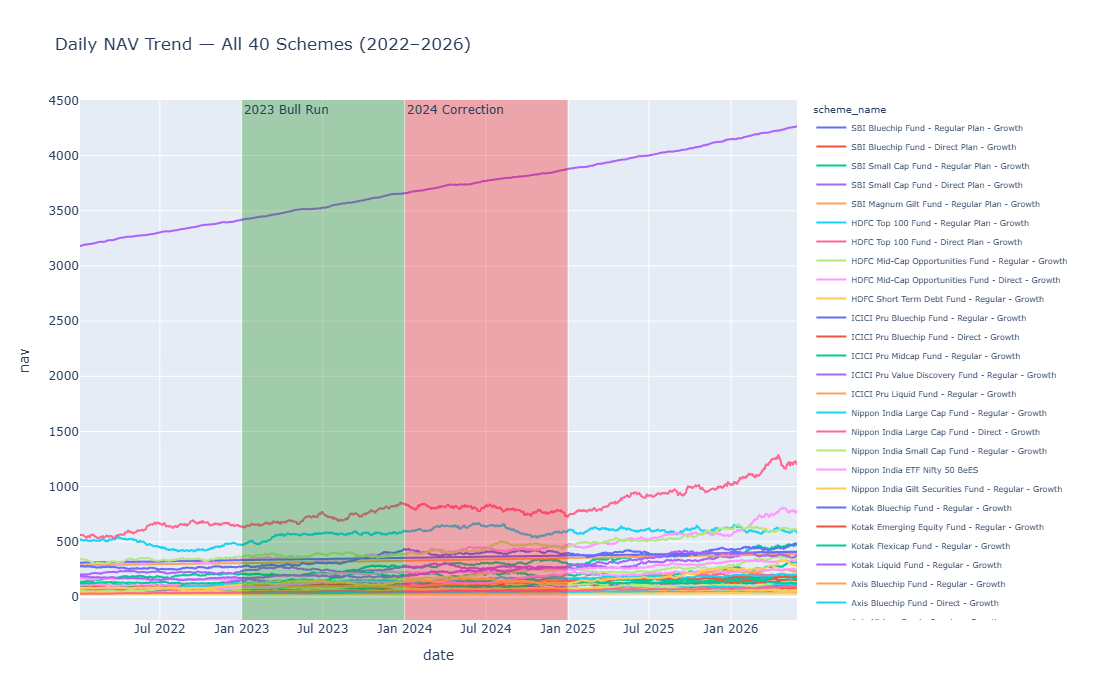

In [28]:
# Build the line chart: one line per scheme_name, x=date, y=nav
fig = px.line(
    nav_scheme,
    x='date',
    y='nav',
    color='scheme_name',  
    title='Daily NAV Trend — All 40 Schemes (2022–2026)'
)
# Highlight the 2023 bull run — shaded green band
fig.add_vrect(
    x0='2023-01-01', x1='2023-12-31',
    fillcolor='green', opacity=0.3, line_width=0,
    annotation_text='2023 Bull Run', annotation_position='top left'
)
# Highlight the 2024 correction — shaded red band
fig.add_vrect(
    x0='2024-01-01', x1='2024-12-31',
    fillcolor='red', opacity=0.3, line_width=0,
    annotation_text='2024 Correction', annotation_position='top left'
)
fig.update_layout(legend=dict(font=dict(size=8)), height=700)
fig.show()

In [30]:
aum_by_fund_house=pd.read_csv(r"C:\Users\aksha\OneDrive\Desktop\BLUE STOCK INTERNSHIP\Mutual-Fund-Analysis\data\processed\aum_by_fund_house_cleaned.csv")

### AUM growth bar chart

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
aum_by_fund_house.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [40]:
aum_by_fund_house['date']=pd.to_datetime(aum_by_fund_house['date'])

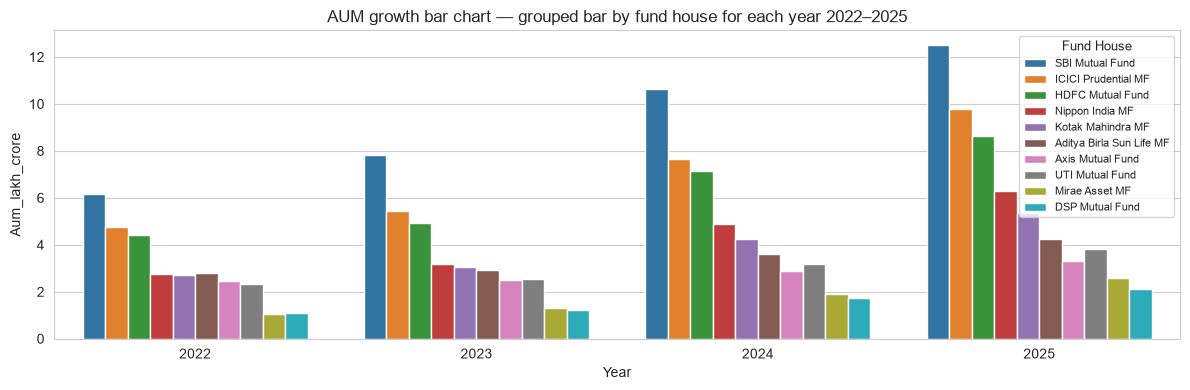

In [61]:
plt.figure(figsize=(12,4))
sns.set_style('whitegrid')

fig=sns.barplot(x=aum_by_fund_house['date'].dt.year,y='aum_lakh_crore',hue='fund_house',
                data=aum_by_fund_house,errorbar=None)
plt.title('AUM growth bar chart — grouped bar by fund house for each year 2022–2025')
plt.xlabel('Year')
plt.ylabel('Aum_lakh_crore')
plt.legend(title='Fund House', fontsize=8, title_fontsize=9)
plt.tight_layout()

plt.show()

### SIP inflow time-series 

In [62]:
monthly_sip_inflows=pd.read_csv(r"C:\Users\aksha\OneDrive\Desktop\BLUE STOCK INTERNSHIP\Mutual-Fund-Analysis\data\processed\monthly_sip_inflows_cleaned.csv")

In [66]:
monthly_sip_inflows['month']=pd.to_datetime(monthly_sip_inflows['month'])

In [67]:
monthly_sip_inflows.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN


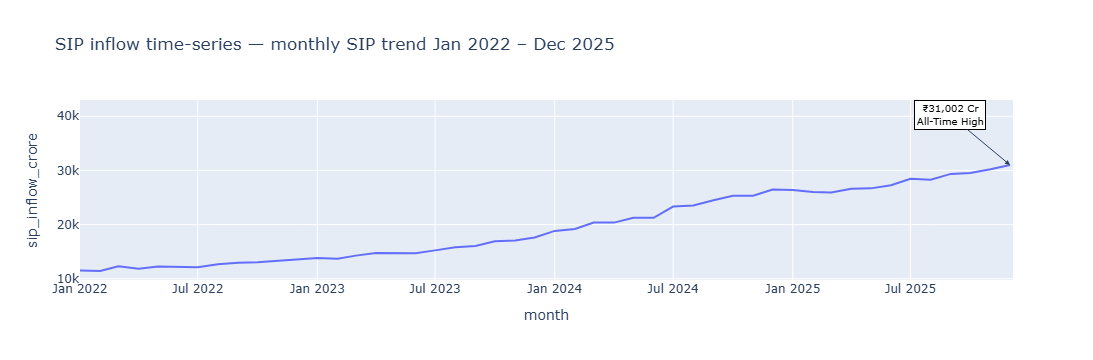

In [78]:
fig=px.line(
    monthly_sip_inflows,
    x='month',
    y='sip_inflow_crore',
    title='SIP inflow time-series — monthly SIP trend Jan 2022 – Dec 2025')

fig.add_annotation(
    x='2025-12-01',      # or pd.Timestamp('2025-12-01')
    y=31002,
    text='₹31,002 Cr<br>All-Time High',
    showarrow=True,
    arrowhead=2,
    ax=-60,
    ay=-50,
    bgcolor='white',
    bordercolor='black',
    font=dict(size=10, color='black')
)
fig.show()

### Category inflow heatmap

In [79]:
category_inflows=pd.read_csv(r"C:\Users\aksha\OneDrive\Desktop\BLUE STOCK INTERNSHIP\Mutual-Fund-Analysis\data\processed\category_inflows_cleaned.csv")

In [81]:
category_inflows.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0
